In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # points to src/systematic_trading

from data.resampled_data_loader import get_resampled_quotes
import datetime as dt
import pandas as pd


traded_instruments = [
    "AUDUSD",
    "EURUSD",
    "GBPUSD",
    "EURGBP",
    "EURJPY",
    "USDJPY",
    "USDCHF",
    "EURCHF",
    "USDCAD",
    "USDZAR",
    "USDPLN",
    "EURPLN",
    "USDNOK",
    "USDSEK",
    "EURNOK",
    "EURSEK",
    "USDSGD",
    "USDMXN",
    "NZDUSD",
]

marketdata_instruments = traded_instruments # + ["UDXUSD", "XAUUSD"]

price_dict = get_resampled_quotes(
    marketdata_instruments,
    dt.date(2023, 1, 1),
    dt.date(2025, 12, 31),
)

In [ ]:
import importlib
import strategy.factor_mean_reversion_strategy as fmrs

importlib.reload(fmrs)
from strategy.factor_mean_reversion_strategy import FactorMeanReversionStrategy

strategy = FactorMeanReversionStrategy(
    instruments=traded_instruments,
    close_price_dict=price_dict,
    hyper_param_dict={
        "zs_entry_threshold": 2,
        "zs_exit_threshold": 0,
        "spread_entry_multiplier": 5,
        "residual_rolling_lookback": pd.Timedelta(minutes=120),
        "n_components": 1
    },
)

In [14]:
factor_pca_rolling_lookback = pd.Timedelta(days=60)
spread_rolling_lookback = pd.Timedelta(minutes=30)

rets = strategy.compute_mid_returns()

# USD factor
factor = strategy.compute_principal_factor(
    rets,
    method="rolling_pca",
    window=factor_pca_rolling_lookback,
    return_bucket_length=pd.Timedelta(hours=6),
    calc_freq=pd.Timedelta(days=7),
    n_components=1,
)

In [58]:
pair = 'AUDUSD'
ret_pair = rets[pair]

beta, residuals = strategy.rolling_regression(
    ret_pair, factor, window=factor_pca_rolling_lookback
)
cum_resid = residuals.rolling(window=strategy.residual_rolling_lookback).sum()

mean = cum_resid.rolling(window=factor_pca_rolling_lookback).mean()
std = cum_resid.rolling(window=factor_pca_rolling_lookback).std()

z = (cum_resid - mean) / std

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Scatter Plot'}, xlabel='z', ylabel='ret'>)

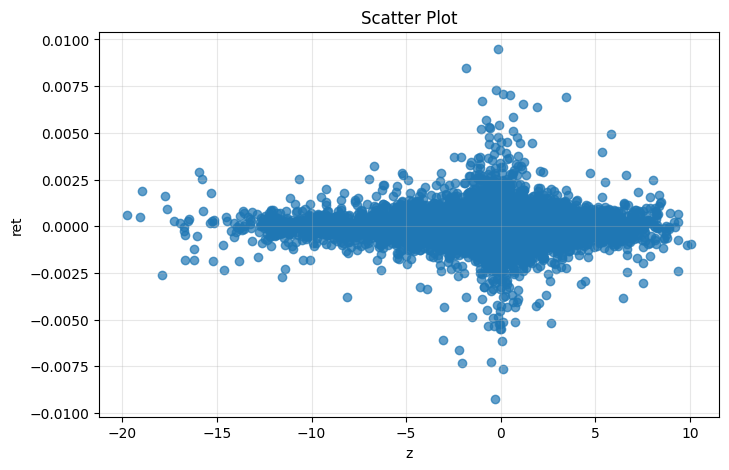

In [78]:
import importlib
import util.plot_util as pu

importlib.reload(pu)
from util.plot_util import plot_series_scatter, plot_ccf

plot_series_scatter(z.shift(1), ret_pair, xlabel="z", ylabel="ret")

In [93]:
from statsmodels.tsa.stattools import adfuller
stat, pvalue, *_ =adfuller(ret_pair[-1000:])
pvalue

0.0

In [4]:
from trading.aggressive_trader import AggressiveTrader

#signals = strategy.generate_signals2()
#signals_nohedge = strategy.generate_signals()
signals_fn = strategy.generate_signals3()

In [ ]:
trader = AggressiveTrader(traded_instruments, price_dict, signals_fn)

In [ ]:
from analytics.markout import Markout
markout = Markout(trader, price_dict)
markout.calculate_markout(plot=True,
                          instruments=['EURSEK'],
                          start_date=dt.date(2025, 6, 1),
                          end_date=dt.date(2025, 7, 2),
                          T_before=pd.Timedelta(minutes=240),
                          T_after=pd.Timedelta(minutes=240))

,markout,weight
time_from_trade,,
-1 days +20:00:00,-0.000276,55.273642
-1 days +20:01:00,-0.000275,55.273642
-1 days +20:02:00,-0.000275,55.273642
-1 days +20:03:00,-0.000280,55.273642
-1 days +20:04:00,-0.000259,55.273642
...,...,...
0 days 03:56:00,-0.000204,55.273642
0 days 03:57:00,-0.000184,55.273642
0 days 03:58:00,-0.000183,55.273642


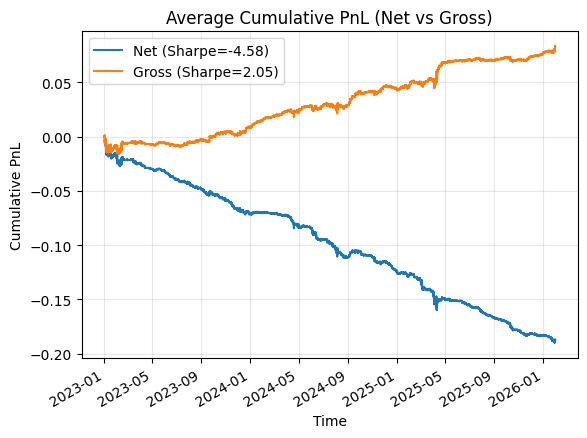

In [6]:
import numpy as np

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * 24 * 60) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * 24 * 60) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [7]:
from analytics.performance_report import PerformanceReport

report = PerformanceReport(traded_instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
AUDUSD,-1.317379,-0.125109,11.113677,-0.213829,-0.024611,-0.000016,-0.000002,0 days 00:13:42.551928,0 days 00:06:00,0 days 00:01:00,0 days 00:30:00
EURUSD,-0.772314,-0.389995,13.468917,-0.131606,-0.018988,-0.000007,-0.000003,0 days 00:12:51.357898,0 days 00:07:00,0 days 00:01:00,0 days 00:27:00
GBPUSD,0.122414,0.791122,12.767318,-0.052685,-0.015003,0.000001,0.000008,0 days 00:12:34.743174,0 days 00:07:00,0 days 00:01:00,0 days 00:28:00
EURGBP,-0.394236,1.336885,13.341918,-0.065333,-0.011864,-0.000002,0.000008,0 days 00:12:37.619719,0 days 00:07:00,0 days 00:01:00,0 days 00:28:00
EURJPY,-1.064088,-0.379734,10.902309,-0.218038,-0.03007,-0.000015,-0.000005,0 days 00:13:42.036782,0 days 00:07:00,0 days 00:01:00,0 days 00:31:00
USDJPY,-0.694096,-0.287542,10.379218,-0.144439,-0.021759,-0.00001,-0.000004,0 days 00:13:55.800459,0 days 00:07:00,0 days 00:01:00,0 days 00:30:00
USDCHF,-0.991048,0.159792,12.762877,-0.167559,-0.024533,-0.000011,0.000002,0 days 00:12:27.670915,0 days 00:06:00,0 days 00:01:00,0 days 00:27:00
EURCHF,-0.729309,1.135481,12.790409,-0.108801,-0.013374,-0.000006,0.000009,0 days 00:12:06.361311,0 days 00:06:00,0 days 00:01:00,0 days 00:27:00
USDCAD,-0.893674,0.436115,11.300178,-0.094134,-0.010274,-0.000007,0.000003,0 days 00:12:19.647328,0 days 00:06:00,0 days 00:01:00,0 days 00:28:00
USDZAR,-2.598823,0.16216,13.092444,-0.614229,-0.019326,-0.000041,0.000002,0 days 00:12:48.480839,0 days 00:07:00,0 days 00:01:00,0 days 00:28:00


In [ ]:
from analytics.plot_daily_recap import plot_daily_recap

instrument = "USDPLN"
date_range = (dt.date(2025, 9, 2), dt.date(2025, 9, 30))
close_price_df = price_dict[instrument]
plot_daily_recap(instrument, date_range, close_price_df, strategy, trader)

In [ ]:
import importlib
import analytics.hyperparam_optimizer as ho

importlib.reload(ho)

import pandas as pd
from analytics.hyperparam_optimizer import optimize_factor_mean_reversion_hyperparams

param_grid = {
    "zs_entry_threshold": [2.0, 3.0],
    "zs_exit_threshold": [0.0],
    "spread_entry_multiplier": [5.0],
    "residual_rolling_lookback": [
        #pd.Timedelta("10min"),
        pd.Timedelta("20min"),
        #pd.Timedelta("30min"),
        #pd.Timedelta("45min"),
        #pd.Timedelta("1h"),
        pd.Timedelta("2h"),
        #pd.Timedelta("3h"),
        pd.Timedelta("4h"),
        pd.Timedelta("12h"),
    ],
    "n_components" : [1],
}

result = optimize_factor_mean_reversion_hyperparams(
    instruments=traded_instruments,
    close_price_dict=price_dict,
    param_grid=param_grid,
    log_path="hyperparam_trials3.csv",
    checkpoint_every=5,
)

print(result.best_sharpe_by_pair)      # best Sharpe + params per pair
print(result.elapsed_seconds)           # timer harness total runtime
print(result.total_trials, result.log_path)


        best_sharpe_net                                        best_params
AUDUSD        -0.331703  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURCHF        -0.285916  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURGBP        -0.050476  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURJPY         0.006295  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURNOK        -0.583021  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURPLN        -0.990797  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURSEK         0.631304  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURUSD         0.111513  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
GBPUSD         0.295789  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
NZDUSD        -0.096093  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
USDCAD         0.216275  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
USDCHF        -0.838074  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
USDJPY        -0.137603  

In [9]:
result.best_sharpe_by_pair.to_csv('best_sharpe_by_pair3.csv')

In [10]:
tmp = pd.read_csv('hyperparam_trials3.csv')

In [11]:
x = tmp[
    (tmp["AUDUSD__AvgTradesPerDay"] > 1)
    & (tmp["AUDUSD__AvgTradesPerDay"] < 10)
    & (tmp["AUDUSD__Sharpe_Net"] > 0)
]
names = ["Sharpe_Net", "Sharpe_Gross", "AvgTradesPerDay", "MaxDrawdown", "WorstDayPnL", "AvgNetPnLPerTrade", "AvgGrossPnLPerTrade",	"AvgPosDur", "MedPosDur", "Q10PosDur", "Q90PosDur"]

["param__zs_entry_threshold", "param__zs_exit_threshold", "param__spread_entry_multiplier", "param__residual_rolling_lookback"] + ["AUDUSD__" + a for a in names]

['param__zs_entry_threshold',
 'param__zs_exit_threshold',
 'param__spread_entry_multiplier',
 'param__residual_rolling_lookback',
 'AUDUSD__Sharpe_Net',
 'AUDUSD__Sharpe_Gross',
 'AUDUSD__AvgTradesPerDay',
 'AUDUSD__MaxDrawdown',
 'AUDUSD__WorstDayPnL',
 'AUDUSD__AvgNetPnLPerTrade',
 'AUDUSD__AvgGrossPnLPerTrade',
 'AUDUSD__AvgPosDur',
 'AUDUSD__MedPosDur',
 'AUDUSD__Q10PosDur',
 'AUDUSD__Q90PosDur']

In [12]:
names = ["Sharpe_Net", "Sharpe_Gross", "AvgTradesPerDay", "MaxDrawdown", "WorstDayPnL", "AvgNetPnLPerTrade", "AvgGrossPnLPerTrade",	"AvgPosDur", "MedPosDur", "Q10PosDur", "Q90PosDur"]
r = []

for instrument in traded_instruments:
    instrument_names = [instrument + "__" + a for a in names]
    x = tmp[(tmp[instrument + '__AvgTradesPerDay']>1) &(tmp[instrument + '__Sharpe_Net']>0.3)]
    x = x[["param__zs_entry_threshold", "param__zs_exit_threshold", "param__spread_entry_multiplier", "param__residual_rolling_lookback"] + instrument_names]
    x = x.rename(columns=dict(zip(instrument_names, names)))
    x["sym"] = instrument
    
    r.append(x)

In [147]:
r

[Empty DataFrame
 Columns: [param__zs_entry_threshold, param__zs_exit_threshold, param__spread_entry_multiplier, param__residual_rolling_lookback, Sharpe_Net, Sharpe_Gross, AvgTradesPerDay, MaxDrawdown, WorstDayPnL, AvgNetPnLPerTrade, AvgGrossPnLPerTrade, AvgPosDur, MedPosDur, Q10PosDur, Q90PosDur, sym]
 Index: [],
 Empty DataFrame
 Columns: [param__zs_entry_threshold, param__zs_exit_threshold, param__spread_entry_multiplier, param__residual_rolling_lookback, Sharpe_Net, Sharpe_Gross, AvgTradesPerDay, MaxDrawdown, WorstDayPnL, AvgNetPnLPerTrade, AvgGrossPnLPerTrade, AvgPosDur, MedPosDur, Q10PosDur, Q90PosDur, sym]
 Index: [],
 Empty DataFrame
 Columns: [param__zs_entry_threshold, param__zs_exit_threshold, param__spread_entry_multiplier, param__residual_rolling_lookback, Sharpe_Net, Sharpe_Gross, AvgTradesPerDay, MaxDrawdown, WorstDayPnL, AvgNetPnLPerTrade, AvgGrossPnLPerTrade, AvgPosDur, MedPosDur, Q10PosDur, Q90PosDur, sym]
 Index: [],
 Empty DataFrame
 Columns: [param__zs_entry_thres